In [1]:
import numpy as np
from pathlib import Path
import pickle
import math
import matplotlib.pyplot as plt

### Effective ranks of the attention matrices

Given a matrix $A\in\mathbb{R}^{d\times d}$, we can compute its **effective rank** as 
$$\text{erank}(A) = \left\lceil\exp\left(-\sum_{i=1}^d p_i\log(p_i) \right)\right\rceil, \quad p_i = \frac{\sigma_i}{\sum_{j=1}^d \sigma_j}$$

where $\{\sigma_j\}_{j=1=}^d$ are the singular values of $A$.

We apply this to the attention rollout matrix of a transformer with $L$ attention layers.

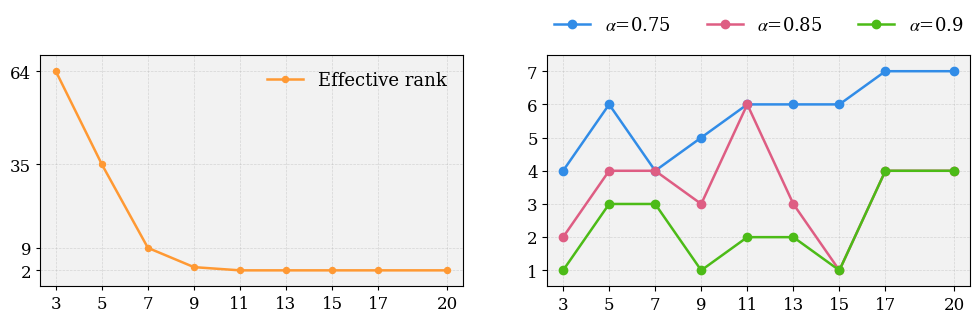

In [55]:
plt.rcParams["font.family"] = "serif"
alpha_color = ["#318CE7", "#DE5D83", "#4CBB17"]

with open("Results/effective_ranks/rollout_ranks.pkl", "rb") as f:
    roll_rank_dict = pickle.load(f)

ALPHAS = [0.75, 0.85, 0.9]
 
depths = [3, 5, 7, 9, 11, 13, 15, 17, 20]
ranks = [math.ceil(v) for v in roll_rank_dict.values()]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# fig, ax = plt.subplots(figsize=(3.35, 2.35), constrained_layout=True)

axes[0].plot(depths, ranks, marker="o", markersize=4.5, color="#FF9933",
             linewidth=1.8, markeredgewidth=0.8, label="Effective rank")

axes[0].set_yticks([ 2, 9, 35, 64])
axes[0].tick_params(axis="both", direction="out", length=3, width=0.8)
axes[0].legend(loc="upper right", frameon=False, fontsize=13)

for i, alpha in enumerate(ALPHAS):
    alpha_s = f"{alpha:.2f}".replace(".", "")

    with open(f"Results/effective_ranks/rollout_counts{alpha_s}.pkl", "rb") as f:
        roll_count_dict_alpha = pickle.load(f)

    ranks = [v['count'] for v in roll_count_dict_alpha.values()]
    axes[1].plot(depths, ranks, marker="o", label=rf"$\alpha$={alpha}", 
                 color=alpha_color[i])

axes[1].legend(ncol=3, frameon=False, fontsize=13, 
               loc="lower center", bbox_to_anchor=(0.5, 1.02))

axes[1].set_yticks([1, 2, 3, 4, 5, 6, 7])

# axes[1].legend(ncol=3, frameon=False, fontsize=12)

for ax in axes:
    ax.set_facecolor("#f2f2f2")
    ax.tick_params(axis='both', labelsize=12)
    ax.margins(x=0.04, y=0.08)
    ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.45)
    ax.set_xticks(depths)

plt.savefig("Results/attention_plots/eff_rank.pdf", bbox_inches="tight")

# fig.savefig(out_dir / "eff_rank.pdf", bbox_inches="tight")
# fig.savefig(out_dir / "eff_rank.png", dpi=600, bbox_inches="tight")
# fig.savefig(out_dir / "eff_rank.svg", bbox_inches="tight")

plt.show()

We can also estimate the number of **relevant columns** in the attention and rollout matrices by computing
$$\rho_{\alpha} = \#\Big\{j\,:\, c_j\geq \alpha\max_{k=1,\ldots,d} c_k\Big\}, \quad\alpha\in (0,1)$$

where $c_j$ indicates the sum of the $j$-ths column. $\rho_{\alpha}$ indicates how many columns in the corresponding matrix have a sum above $\alpha$ times the maximum column sum. It therefore gives an estimate of the $\alpha$ percentage of important columns.

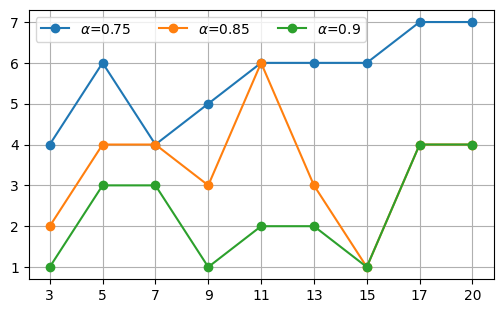

In [6]:
ALPHAS = [0.75, 0.85, 0.9]

plt.figure(figsize=(6, 3.5))

for alpha in ALPHAS:
    alpha_s = f"{alpha:.2f}".replace(".", "")

    with open(f"Results/effective_ranks/rollout_counts{alpha_s}.pkl", "rb") as f:
        roll_count_dict_alpha = pickle.load(f)

    ranks = [v['count'] for v in roll_count_dict_alpha.values()]
    plt.plot(ranks, marker="o", label=rf"$\alpha$={alpha}")    
    
plt.xticks(range(len(ranks)), [3, 5, 7, 9, 11, 13, 15, 17, 20])
plt.legend(ncol=3)

plt.savefig("Results/attention_plots/important_columns.pdf", bbox_inches="tight")
# plt.xlabel("Number of layers")
# plt.ylabel(r"Number of $\alpha$-important columns \n in the rollout matrix")
plt.grid(True)
plt.show()

Finally, using $\rho_{\alpha}$, we can compute the **concentration index** 
$$\mathcal C_{\alpha} = 1-\frac{\rho_\alpha}{d}\in [0,1], \quad\alpha\in (0,1)$$

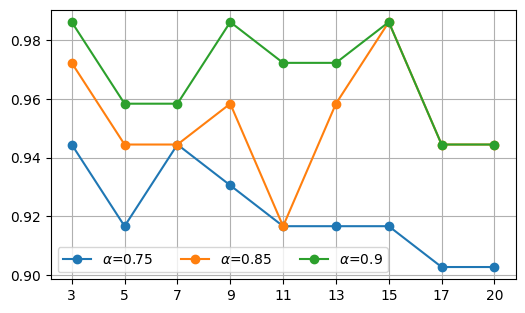

In [7]:
plt.figure(figsize=(6, 3.5))

for alpha in ALPHAS:
    alpha_s = f"{alpha:.2f}".replace(".", "")

    with open(f"Results/effective_ranks/rollout_counts{alpha_s}.pkl", "rb") as f:
        roll_count_dict_alpha = pickle.load(f)

    concentrations = [v['concentration'] for v in roll_count_dict_alpha.values()]
    plt.plot(concentrations, marker="o", label=rf"$\alpha$={alpha}")
    
plt.xticks(range(len(ranks)), [3, 5, 7, 9, 11, 13, 15, 17, 20])
plt.legend(ncol=3)

plt.savefig("Results/attention_plots/concentration.pdf", bbox_inches="tight")

plt.grid(True)
plt.show()